In [5]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Compilación
!g++ -O3 -march=native -o pcap2bin pcap2bin.cpp
!g++ -O3 -march=native -o exact_hh exact_hh.cpp
!g++ -O3 -march=native -o sliding_window_estimator sliding_window_estimator.cpp
print("Compilación completada.")

Compilación completada.


In [4]:
# Descarga y conversión
#!curl -O https://mawi.wide.ad.jp/mawi/samplepoint-F/2018/201812031400.pcap.gz

# Extraer y convertir a binario
#!zcat 201812031400.pcap.gz | ./pcap2bin > traza.bin
#print("Traza binaria 'traza.bin' generada exitosamente.")

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100  2.90G 100  2.90G   0      0  5.37M      0   09:13   09:13          4.89M
pcap: linktype=1 
----------------------------------------------------------
frames leídos      : 132462957
registros escritos : 123383971  (2961.2 MB)
  IPv4             : 123383971
  IPv6             : 9078984 (descartados)
  no-IP descartados: 2
  truncados        : 0
  fragmentos !=0   : 64189  (sin puertos)
  con VLAN         : 0
fuera de orden     : 0
bytes en el cable  : 113562155437
duración           : 899.955314 s
tasa media         : 137100 pkt/s, 1.009 Gbps
----------------------------------------------------------
Traza binaria 'traza.bin' generada exitosamente.


In [5]:
# Obtener Ground Truth y Seleccionar 
# Extraer el comportamiento global de las ventanas y el Top-K
print("Generando ground truth de ventanas y Top-K...")
subprocess.run([
    "./exact_hh", "traza.bin", "--key", "src", "--weight", "pkts", 
    "-W", "60", "--delta", "10", "--phi", "0.01", 
    "--topk", "20", "--out-windows", "win_W60.csv", "--out-topk", "topk_W60.csv"
], check=True)

# Seleccionar automáticamente el mayor Heavy Hitter real
df_topk = pd.read_csv("topk_W60.csv")
target_ip = df_topk['key'].iloc[0]
print(f"Heavy Hitter seleccionado automáticamente: {target_ip}")

# Generar la consulta exacta para esta IP específica
print(f"Generando consulta exacta para {target_ip}...")
subprocess.run([
    "./exact_hh", "traza.bin", "--key", "src", 
    "-W", "60", "--delta", "10", "--phi", "0.01", 
    "--query", target_ip, "--out-query", "exact_query.csv"
], check=True)
print("Ground truth de la consulta generado con éxito.")

Generando ground truth de ventanas y Top-K...
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 352987, máx 381193
memoria de la tabla  : 20.6 MB (máx, estimada)
VmHWM del proceso    : 1257.9 MB (incluye la traza mapeada)
Heavy Hitter seleccionado automáticamente: 203.83.117.211
Generando consulta exacta para 203.83.117.211...
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 352987, máx 381193
memoria de la tabla  : 20.6 MB (máx, estimada)
VmHWM del proceso    : 1256.0 MB (incluye la traza mapeada)
Ground truth de la consulta generado con éxito.


In [ ]:
# Ejecución de los Sketches
d = 5
widths = [256, 1024, 4096]
sketches = ["cm", "cs"]

memory_usage = {}

for sketch in sketches:
    for w in widths:
        # Calcular memoria: 7 matrices * d * w * 8 bytes
        bytes_mem = 7 * d * w * 8
        memory_usage[f"{sketch}_{w}"] = bytes_mem / 1024 # en KB
        
        output_csv = f"output_{sketch}_w{w}.csv"
        
        cmd = f"./sliding_window_estimator traza.bin {sketch} {d} {w} src {target_ip} > {output_csv}"
        print(f"Ejecutando: {cmd}")
        
        # subprocess.run reemplaza a os.system
        subprocess.run(cmd, shell=True, check=True)
        
print("Ejecuciones de sketches completadas.")

Ejecutando: ./sliding_window_estimator traza.bin cm 5 256 src 203.83.117.211 > output_cm_w256.csv
Ejecutando: ./sliding_window_estimator traza.bin cm 5 1024 src 203.83.117.211 > output_cm_w1024.csv
Ejecutando: ./sliding_window_estimator traza.bin cm 5 4096 src 203.83.117.211 > output_cm_w4096.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 256 src 203.83.117.211 > output_cs_w256.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 1024 src 203.83.117.211 > output_cs_w1024.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 4096 src 203.83.117.211 > output_cs_w4096.csv


[CM w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 4931.52
[CM w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 985.24
[CM w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 126.45
[CS w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 2396.08
[CS w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 528.21
[CS w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 112.77


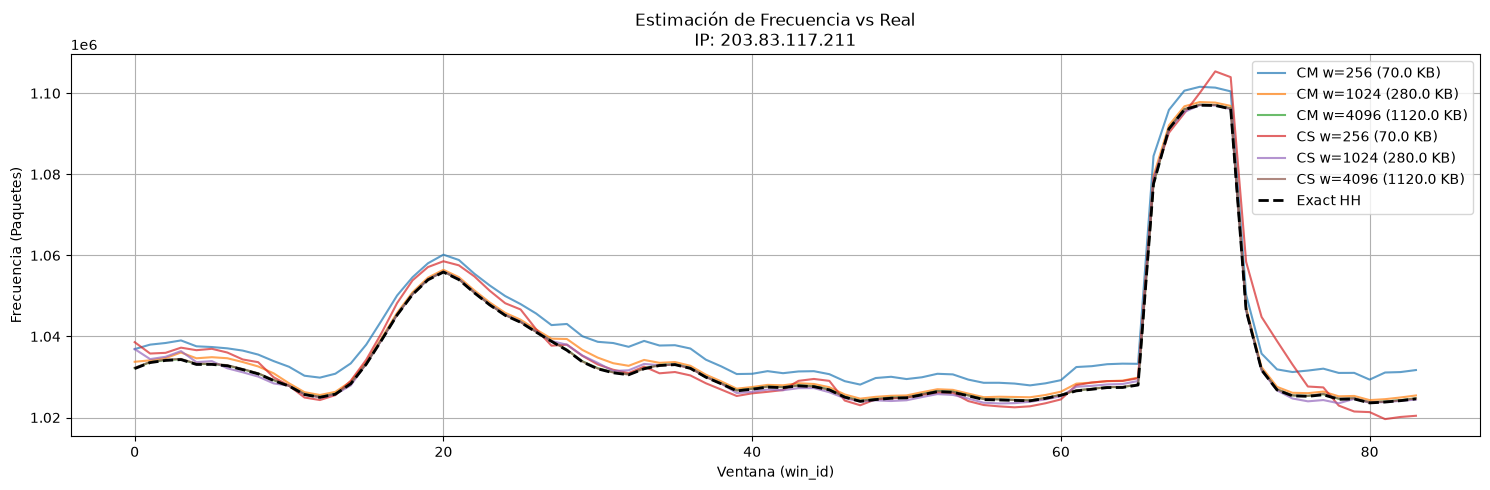

In [14]:
# Verificación Nj, Análisis y Gráficos

# Cargar los ground truths
df_exact_query = pd.read_csv("exact_query.csv")
df_exact_win = pd.read_csv("win_W60.csv")

# Filtrar y renombrar la consulta exacta
df_exact_query = df_exact_query[['tau_us', 'exact_f']].rename(columns={'exact_f': 'f_exact'})

# Para la verificación de N, filtramos win_W60 para tener solo tau_us y N
df_exact_win = df_exact_win[['tau_us', 'N']].rename(columns={'N': 'N_exact'})

fig, ax1 = plt.subplots(figsize=(15, 5))

for sketch in sketches:
    for w in widths:
        df_est = pd.read_csv(f"output_{sketch}_w{w}.csv")
        
        # Verificación del anillo Nj
        # Unimos las ventanas por el tiempo exacto de evaluación
        df_check = pd.merge(df_est, df_exact_win, on='tau_us', suffixes=('_est', '_exact'))
        
        # 'N' es de C++, 'N_exact' viene de win_W60.csv
        if not (df_check['N'] == df_check['N_exact']).all():
            raise AssertionError(f"Desalineación en {sketch} w={w}. Los contadores Nj no coinciden con exact_hh.")
        print(f"[{sketch.upper()} w={w}] Verificación Nj superada (Perfecta alineación).")

        # Unir estimaciones con la frecuencia real de la IP objetivo
        df_merged = pd.merge(df_est, df_exact_query, on='tau_us', how='inner')
        
        # Calcular Errores
        df_merged['abs_err'] = np.abs(df_merged['f_est'] - df_merged['f_exact'])
        df_merged['rel_err'] = df_merged['abs_err'] / df_merged['f_exact'].replace(0, 1)
        
        mean_abs = df_merged['abs_err'].mean()
        label = f"{sketch.upper()} w={w} ({memory_usage[f'{sketch}_{w}']:.1f} KB)"
        print(f"   -> Error Absoluto Medio: {mean_abs:.2f}")
        
        # Graficar en el Plot 1
        ax1.plot(df_merged['win'], df_merged['f_est'], label=label, alpha=0.7)

# Graficar la línea base del ground truth
ax1.plot(df_merged['win'], df_merged['f_exact'], 'k--', linewidth=2, label='Exact HH')

ax1.set_title(f"Estimación de Frecuencia vs Real\nIP: {target_ip}")
ax1.set_xlabel("Ventana (win_id)")
ax1.set_ylabel("Frecuencia (Paquetes)")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()

In [1]:
## Generación de trazas con ataques
!./inject_attack.py ddos \
    --base traza.bin \
    --out traza_ddos.bin \
    --gt gt_ddos.json \
    --start 300 \
    --duration 30 \
    --pps 10000 \
    --sources 4000

!./inject_attack.py scan \
    --base traza.bin \
    --out traza_scan.bin \
    --gt gt_scan.json \
    --start 300 \
    --duration 30 \
    --pps 8000 \
    --dst-count 60000

!ls -lh traza_ddos.bin traza_scan.bin gt_ddos.json gt_scan.json

victima automatica: rango 1000 en la muestra, 33 paquetes previos
--------------------------------------------------------
ataque             : ddos
traza base         : 123383971 registros, 899.955 s
inyectados         : 300000 paquetes (0.2426% del total), 19.20 MB
intervalo          : [300.00, 330.00] s desde el inicio
salida             : traza_ddos.bin (123683971 registros)
ground truth       : gt_ddos.json
--------------------------------------------------------
--------------------------------------------------------
ataque             : scan
traza base         : 123383971 registros, 899.955 s
inyectados         : 240000 paquetes (0.1941% del total), 15.36 MB
intervalo          : [300.00, 330.00] s desde el inicio
salida             : traza_scan.bin (123623971 registros)
ground truth       : gt_scan.json
--------------------------------------------------------
-rw-rw-r-- 1 ethan ethan 1.7K Sep 27 17:14 gt_ddos.json
-rw-rw-r-- 1 ethan ethan 1.1K Sep 27 17:14 gt_scan.json
-rw-rw-r

In [2]:
# Obtener las claves de ataque desde los archivos de ground truth
import json
import subprocess

with open("gt_ddos.json", "r") as f:
    gt_ddos = json.load(f)

with open("gt_scan.json", "r") as f:
    gt_scan = json.load(f)

victima_ddos = gt_ddos["ataque"]["victima"]
atacante_scan = gt_scan["ataque"]["atacante"]

print(f"Víctima DDoS: {victima_ddos}")
print(f"Atacante scan: {atacante_scan}")

# Calcular la frecuencia exacta de la víctima del DDoS por IP de destino
subprocess.run([
    "./exact_hh",
    "traza_ddos.bin",
    "--key", "dst",
    "-W", "60",
    "--delta", "10",
    "--phi", "0.01",
    "--query", victima_ddos,
    "--out-query", "exact_ddos.csv"
], check=True)

# Calcular la frecuencia exacta del atacante del scan por IP de origen
subprocess.run([
    "./exact_hh",
    "traza_scan.bin",
    "--key", "src",
    "-W", "60",
    "--delta", "10",
    "--phi", "0.01",
    "--query", atacante_scan,
    "--out-query", "exact_scan.csv"
], check=True)

print("Ground truth exacto generado correctamente.")

Víctima DDoS: 91.27.86.11
Atacante scan: 198.18.0.7
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 1245390, máx 1319692
memoria de la tabla  : 59.4 MB (máx, estimada)
VmHWM del proceso    : 783.0 MB (incluye la traza mapeada)
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 352987, máx 381193
memoria de la tabla  : 20.6 MB (máx, estimada)
VmHWM del proceso    : 714.3 MB (incluye la traza mapeada)
Ground truth exacto generado correctamente.


In [3]:
# Ejecución de los Sketches
d = 5
widths = [256, 1024, 4096]
sketches = ["cm", "cs"]

memory_usage = {}

# Configuración de los ataques
ataques = {
    "ddos": {
        "traza": "traza_ddos.bin",
        "key_type": "dst",
        "target_ip": victima_ddos
    },
    "scan": {
        "traza": "traza_scan.bin",
        "key_type": "src",
        "target_ip": atacante_scan
    }
}

for ataque, config in ataques.items():
    for sketch in sketches:
        for w in widths:
            # Calcular memoria: 7 matrices * d * w * 8 bytes
            bytes_mem = 7 * d * w * 8
            memory_usage[f"{sketch}_{w}"] = bytes_mem / 1024  # en KB
            
            output_csv = f"output_{ataque}_{sketch}_w{w}.csv"
            
            cmd = (
                f"./sliding_window_estimator "
                f"{config['traza']} "
                f"{sketch} {d} {w} "
                f"{config['key_type']} "
                f"{config['target_ip']} "
                f"> {output_csv}"
            )
            
            print(f"Ejecutando: {cmd}")
            
            # subprocess.run reemplaza a os.system
            subprocess.run(cmd, shell=True, check=True)

print("Ejecuciones de sketches completadas.")

Ejecutando: ./sliding_window_estimator traza_ddos.bin cm 5 256 dst 91.27.86.11 > output_ddos_cm_w256.csv
Ejecutando: ./sliding_window_estimator traza_ddos.bin cm 5 1024 dst 91.27.86.11 > output_ddos_cm_w1024.csv
Ejecutando: ./sliding_window_estimator traza_ddos.bin cm 5 4096 dst 91.27.86.11 > output_ddos_cm_w4096.csv
Ejecutando: ./sliding_window_estimator traza_ddos.bin cs 5 256 dst 91.27.86.11 > output_ddos_cs_w256.csv
Ejecutando: ./sliding_window_estimator traza_ddos.bin cs 5 1024 dst 91.27.86.11 > output_ddos_cs_w1024.csv
Ejecutando: ./sliding_window_estimator traza_ddos.bin cs 5 4096 dst 91.27.86.11 > output_ddos_cs_w4096.csv
Ejecutando: ./sliding_window_estimator traza_scan.bin cm 5 256 src 198.18.0.7 > output_scan_cm_w256.csv
Ejecutando: ./sliding_window_estimator traza_scan.bin cm 5 1024 src 198.18.0.7 > output_scan_cm_w1024.csv
Ejecutando: ./sliding_window_estimator traza_scan.bin cm 5 4096 src 198.18.0.7 > output_scan_cm_w4096.csv
Ejecutando: ./sliding_window_estimator traza_s


===== DDOS =====
[CM w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 7084.38
[CM w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 1389.18
[CM w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 323.57
[CS w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 985.37
[CS w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 40.98
[CS w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 20.61


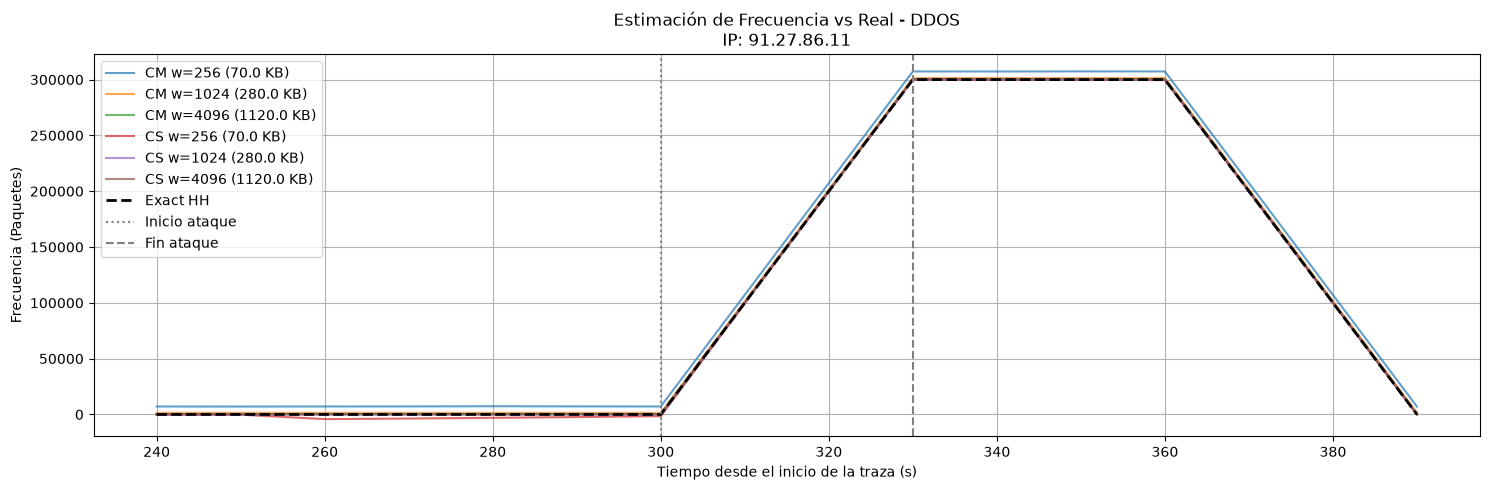


===== SCAN =====
[CM w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 11739.69
[CM w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 787.68
[CM w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 123.62
[CS w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 7658.93
[CS w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 472.44
[CS w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 31.55


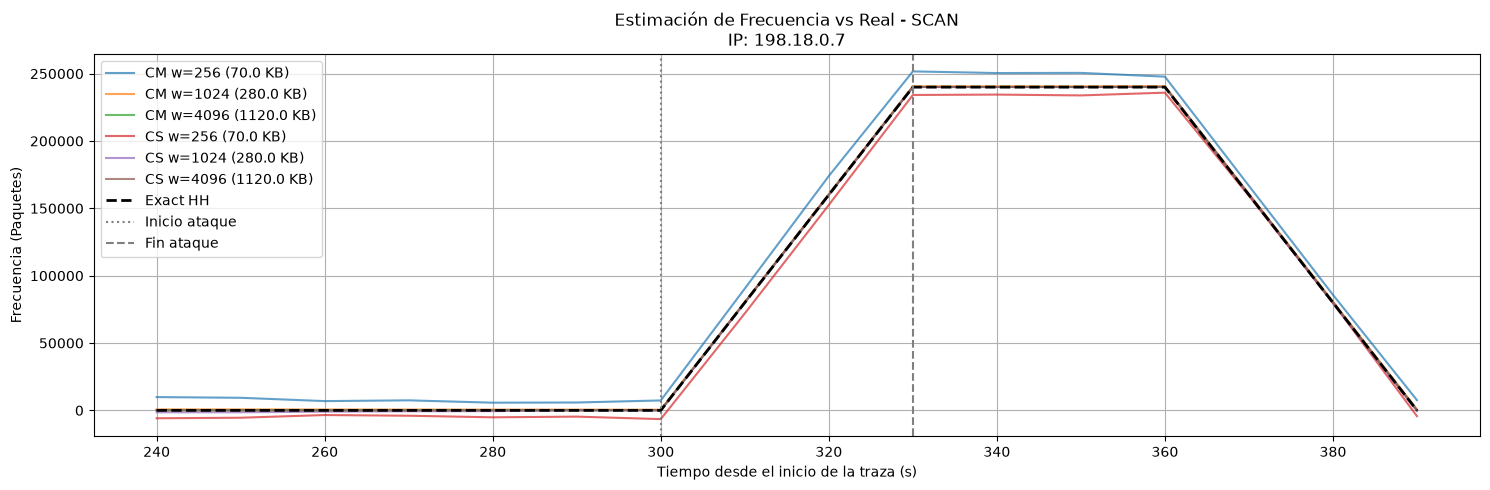

In [13]:
# Verificación Nj, Análisis y Gráficos

# Configuración de los ataques
ataques = {
    "ddos": {
        "exact_csv": "exact_ddos.csv",
        "target_ip": victima_ddos,
        "inicio": 300,
        "fin": 330
    },
    "scan": {
        "exact_csv": "exact_scan.csv",
        "target_ip": atacante_scan,
        "inicio": 300,
        "fin": 330
    }
}

# Guardar los resultados para utilizarlos después
resultados = {}

for ataque, config in ataques.items():

    print(f"\n===== {ataque.upper()} =====")

    # Cargar el ground truth
    df_exact = pd.read_csv(config["exact_csv"])

    # Filtrar y renombrar la consulta exacta
    df_exact_query = df_exact[
        ['tau_us', 't_rel_s', 'exact_f', 'exact_hh']
    ].rename(columns={'exact_f': 'f_exact'})

    # Para la verificación de N
    df_exact_win = df_exact[
        ['tau_us', 'N']
    ].rename(columns={'N': 'N_exact'})

    fig, ax1 = plt.subplots(figsize=(15, 5))

    for sketch in sketches:
        for w in widths:

            df_est = pd.read_csv(
                f"output_{ataque}_{sketch}_w{w}.csv"
            )

            # Verificación del anillo Nj
            # Unimos las ventanas por el tiempo exacto de evaluación
            df_check = pd.merge(
                df_est,
                df_exact_win,
                on='tau_us',
                suffixes=('_est', '_exact')
            )

            # 'N' es de C++, 'N_exact' viene del ground truth
            if not (df_check['N'] == df_check['N_exact']).all():
                raise AssertionError(
                    f"Desalineación en {ataque} - {sketch} w={w}. "
                    "Los contadores Nj no coinciden con exact_hh."
                )

            print(
                f"[{sketch.upper()} w={w}] "
                "Verificación Nj superada (Perfecta alineación)."
            )

            # Unir estimaciones con la frecuencia real de la IP objetivo
            df_merged = pd.merge(
                df_est,
                df_exact_query,
                on='tau_us',
                how='inner'
            )

            # Calcular Errores
            df_merged['abs_err'] = np.abs(
                df_merged['f_est'] - df_merged['f_exact']
            )

            df_merged['rel_err'] = np.where(
                df_merged['f_exact'] > 0,
                df_merged['abs_err'] / df_merged['f_exact'],
                np.nan
            )

            mean_abs = df_merged['abs_err'].mean()

            label = (
                f"{sketch.upper()} w={w} "
                f"({memory_usage[f'{sketch}_{w}']:.1f} KB)"
            )

            print(
                f"   -> Error Absoluto Medio: {mean_abs:.2f}"
            )

            # Guardar el resultado para análisis posteriores
            resultados[(ataque, sketch, w)] = df_merged

            # Mostrar solamente desde 60 s antes del ataque
            # hasta 60 s después de su final
            df_plot = df_merged[
                (df_merged['t_rel_s'] >= config["inicio"] - 60) &
                (df_merged['t_rel_s'] <= config["fin"] + 60)
            ]

            # Graficar estimaciones
            ax1.plot(
                df_plot['t_rel_s'],
                df_plot['f_est'],
                label=label,
                alpha=0.7
            )

    # Ground truth en el mismo intervalo
    df_exact_plot = df_exact_query[
        (df_exact_query['t_rel_s'] >= config["inicio"] - 60) &
        (df_exact_query['t_rel_s'] <= config["fin"] + 60)
    ]

    ax1.plot(
        df_exact_plot['t_rel_s'],
        df_exact_plot['f_exact'],
        'k--',
        linewidth=2,
        label='Exact HH'
    )

    # Marcar inicio y fin del ataque
    ax1.axvline(
        config["inicio"],
        color='gray',
        linestyle=':',
        label='Inicio ataque'
    )

    ax1.axvline(
        config["fin"],
        color='gray',
        linestyle='--',
        label='Fin ataque'
    )

    ax1.set_title(
        f"Estimación de Frecuencia vs Real - {ataque.upper()}\n"
        f"IP: {config['target_ip']}"
    )

    ax1.set_xlabel("Tiempo desde el inicio de la traza (s)")
    ax1.set_ylabel("Frecuencia (Paquetes)")
    ax1.legend()
    ax1.grid(True)
    
    plt.tight_layout()
    
    # Guardar la figura para el informe
    plt.savefig(
        f"figuras/{ataque}_frecuencia.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [10]:
# Cálculo del MRE y error relativo por ventana

mre_results = []
errores_ventana = []

W = 60

for ataque, config in ataques.items():

    print(f"\n===== {ataque.upper()} =====")

    for sketch in sketches:
        for w in widths:

            # Los datos ya fueron calculados y guardados en la celda anterior
            df = resultados[(ataque, sketch, w)]

            # Ventanas afectadas por el ataque:
            # posteriores al inicio y anteriores a que todos
            # los paquetes del ataque hayan salido de la ventana
            df_afectado = df[
                (df['t_rel_s'] > config["inicio"]) &
                (df['t_rel_s'] < config["fin"] + W) &
                (df['f_exact'] > 0)
            ].copy()

            # MRE
            mre = df_afectado['rel_err'].mean()

            mre_results.append({
                "ataque": ataque,
                "sketch": sketch.upper(),
                "w": w,
                "memoria_KB": memory_usage[f"{sketch}_{w}"],
                "MRE": mre
            })

            print(
                f"{sketch.upper()} w={w} -> "
                f"MRE = {mre:.4f} ({mre * 100:.2f} %)"
            )

            # Guardar el error de cada ventana
            for _, row in df_afectado.iterrows():
                errores_ventana.append({
                    "ataque": ataque,
                    "sketch": sketch.upper(),
                    "w": w,
                    "tiempo_s": row["t_rel_s"],
                    "f_exact": row["f_exact"],
                    "f_est": row["f_est"],
                    "error_relativo": row["rel_err"]
                })

# Tabla resumen del MRE
df_mre = pd.DataFrame(mre_results)

# Tabla con el error relativo de cada ventana
df_errores_ventana = pd.DataFrame(errores_ventana)

display(df_mre)
display(df_errores_ventana)


===== DDOS =====
CM w=256 -> MRE = 0.0391 (3.91 %)
CM w=1024 -> MRE = 0.0077 (0.77 %)
CM w=4096 -> MRE = 0.0018 (0.18 %)
CS w=256 -> MRE = 0.0018 (0.18 %)
CS w=1024 -> MRE = 0.0003 (0.03 %)
CS w=4096 -> MRE = 0.0001 (0.01 %)

===== SCAN =====
CM w=256 -> MRE = 0.0625 (6.25 %)
CM w=1024 -> MRE = 0.0044 (0.44 %)
CM w=4096 -> MRE = 0.0008 (0.08 %)
CS w=256 -> MRE = 0.0307 (3.07 %)
CS w=1024 -> MRE = 0.0011 (0.11 %)
CS w=4096 -> MRE = 0.0004 (0.04 %)


,ataque,sketch,w,memoria_KB,MRE
0,ddos,CM,256,70.0,0.039060
1,ddos,CM,1024,280.0,0.007682
2,ddos,CM,4096,1120.0,0.001846
3,ddos,CS,256,70.0,0.001772
4,ddos,CS,1024,280.0,0.000306
5,ddos,CS,4096,1120.0,0.000074
6,scan,CM,256,70.0,0.062543
7,scan,CM,1024,280.0,0.004418
8,scan,CM,4096,1120.0,0.000803
9,scan,CS,256,70.0,0.030665


,ataque,sketch,w,tiempo_s,f_exact,f_est,error_relativo
0,ddos,CM,256,310.0,100000,107171,0.071710
1,ddos,CM,256,320.0,200000,207289,0.036445
2,ddos,CM,256,330.0,300000,307297,0.024323
3,ddos,CM,256,340.0,300000,307252,0.024173
4,ddos,CM,256,350.0,300000,307347,0.024490
...,...,...,...,...,...,...,...
91,scan,CS,4096,340.0,240000,240057,0.000237
92,scan,CS,4096,350.0,240000,240062,0.000258
93,scan,CS,4096,360.0,240000,240042,0.000175
94,scan,CS,4096,370.0,160000,160054,0.000338


In [9]:
# Análisis de la detección: latencia, falsos positivos y falsos negativos

latency_results = []

W = 60

for ataque, config in ataques.items():

    print(f"\n===== {ataque.upper()} =====")

    # Cargar el ground truth
    df_exact = pd.read_csv(config["exact_csv"])

    # Primera detección exacta del ataque
    detecciones_exactas = df_exact[
        (df_exact['t_rel_s'] >= config["inicio"]) &
        (df_exact['exact_hh'] == 1)
    ]

    if len(detecciones_exactas) > 0:
        tiempo_exact = detecciones_exactas.iloc[0]['t_rel_s']
        latencia_exact = tiempo_exact - config["inicio"]
    else:
        tiempo_exact = np.nan
        latencia_exact = np.nan

    print(
        f"Exacto -> primera detección: {tiempo_exact:.0f} s, "
        f"latencia: {latencia_exact:.0f} s"
    )

    for sketch in sketches:
        for w in widths:

            df = resultados[(ataque, sketch, w)].copy()

            # Analizar desde el inicio del ataque hasta que todos
            # los paquetes del ataque hayan salido de la ventana
            df_periodo = df[
                (df['t_rel_s'] >= config["inicio"]) &
                (df['t_rel_s'] <= config["fin"] + W)
            ].copy()

            # Primera alerta generada por el sketch
            alertas = df_periodo[
                df_periodo['is_hh'] == 1
            ]

            if len(alertas) > 0:
                tiempo_alerta = alertas.iloc[0]['t_rel_s']
                latencia_alerta = tiempo_alerta - config["inicio"]
            else:
                tiempo_alerta = np.nan
                latencia_alerta = np.nan

            # Primera detección correcta:
            # el sketch y el ground truth indican HH al mismo tiempo
            detecciones_correctas = df_periodo[
                (df_periodo['is_hh'] == 1) &
                (df_periodo['exact_hh'] == 1)
            ]

            if len(detecciones_correctas) > 0:
                tiempo_correcto = detecciones_correctas.iloc[0]['t_rel_s']
                latencia_correcta = tiempo_correcto - config["inicio"]
            else:
                tiempo_correcto = np.nan
                latencia_correcta = np.nan

            # Falsos positivos:
            # el sketch dice HH, pero el ground truth dice que no
            falsos_positivos = df_periodo[
                (df_periodo['is_hh'] == 1) &
                (df_periodo['exact_hh'] == 0)
            ]

            # Falsos negativos:
            # el ground truth dice HH, pero el sketch no lo detecta
            falsos_negativos = df_periodo[
                (df_periodo['is_hh'] == 0) &
                (df_periodo['exact_hh'] == 1)
            ]

            n_fp = len(falsos_positivos)
            n_fn = len(falsos_negativos)

            # Determinar si la primera alerta fue correcta o anticipada
            if len(alertas) == 0:
                tipo_primera_alerta = "Sin alerta"
            elif alertas.iloc[0]['exact_hh'] == 1:
                tipo_primera_alerta = "Correcta"
            else:
                tipo_primera_alerta = "Falso positivo"

            latency_results.append({
                "ataque": ataque,
                "sketch": sketch.upper(),
                "w": w,
                "primera_alerta_s": tiempo_alerta,
                "tipo_primera_alerta": tipo_primera_alerta,
                "latencia_alerta_s": latencia_alerta,
                "primera_deteccion_correcta_s": tiempo_correcto,
                "latencia_correcta_s": latencia_correcta,
                "latencia_exacta_s": latencia_exact,
                "falsos_positivos": n_fp,
                "falsos_negativos": n_fn
            })

            print(
                f"{sketch.upper()} w={w} -> "
                f"primera alerta: {tiempo_alerta:.0f} s "
                f"({tipo_primera_alerta}), "
                f"primera detección correcta: {tiempo_correcto:.0f} s, "
                f"latencia correcta: {latencia_correcta:.0f} s, "
                f"FP: {n_fp}, FN: {n_fn}"
            )

# Tabla resumen
df_latency = pd.DataFrame(latency_results)

df_latency


===== DDOS =====
Exacto -> primera detección: 310 s, latencia: 10 s
CM w=256 -> primera alerta: 310 s (Correcta), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 0, FN: 0
CM w=1024 -> primera alerta: 310 s (Correcta), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 0, FN: 0
CM w=4096 -> primera alerta: 310 s (Correcta), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 0, FN: 0
CS w=256 -> primera alerta: 300 s (Falso positivo), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 2, FN: 0
CS w=1024 -> primera alerta: 310 s (Correcta), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 0, FN: 0
CS w=4096 -> primera alerta: 300 s (Falso positivo), primera detección correcta: 310 s, latencia correcta: 10 s, FP: 2, FN: 0

===== SCAN =====
Exacto -> primera detección: 320 s, latencia: 20 s
CM w=256 -> primera alerta: 310 s (Falso positivo), primera detección correcta: 320 s, latencia correcta: 20 s, FP: 2, FN: 0
CM w=10

,ataque,sketch,w,primera_alerta_s,tipo_primera_alerta,latencia_alerta_s,primera_deteccion_correcta_s,latencia_correcta_s,latencia_exacta_s,falsos_positivos,falsos_negativos
0,ddos,CM,256,310.0,Correcta,10.0,310.0,10.0,10.0,0,0
1,ddos,CM,1024,310.0,Correcta,10.0,310.0,10.0,10.0,0,0
2,ddos,CM,4096,310.0,Correcta,10.0,310.0,10.0,10.0,0,0
3,ddos,CS,256,300.0,Falso positivo,0.0,310.0,10.0,10.0,2,0
4,ddos,CS,1024,310.0,Correcta,10.0,310.0,10.0,10.0,0,0
5,ddos,CS,4096,300.0,Falso positivo,0.0,310.0,10.0,10.0,2,0
6,scan,CM,256,310.0,Falso positivo,10.0,320.0,20.0,20.0,2,0
7,scan,CM,1024,320.0,Correcta,20.0,320.0,20.0,20.0,0,0
8,scan,CM,4096,320.0,Correcta,20.0,320.0,20.0,20.0,0,0
9,scan,CS,256,300.0,Falso positivo,0.0,320.0,20.0,20.0,2,0


In [11]:
# Tabla resumen: precisión, memoria y latencia

df_resumen = pd.merge(
    df_mre,
    df_latency[
        [
            "ataque",
            "sketch",
            "w",
            "primera_alerta_s",
            "tipo_primera_alerta",
            "latencia_alerta_s",
            "latencia_exacta_s",
            "falsos_positivos",
            "falsos_negativos"
        ]
    ],
    on=["ataque", "sketch", "w"],
    how="inner"
)

# Mostrar el MRE como porcentaje para facilitar la lectura
df_resumen["MRE_%"] = df_resumen["MRE"] * 100

# Orden de columnas para el informe
df_resumen = df_resumen[
    [
        "ataque",
        "sketch",
        "w",
        "memoria_KB",
        "MRE_%",
        "primera_alerta_s",
        "latencia_alerta_s",
        "latencia_exacta_s",
        "tipo_primera_alerta",
        "falsos_positivos",
        "falsos_negativos"
    ]
]

df_resumen

,ataque,sketch,w,memoria_KB,MRE_%,primera_alerta_s,latencia_alerta_s,latencia_exacta_s,tipo_primera_alerta,falsos_positivos,falsos_negativos
0,ddos,CM,256,70.0,3.905958,310.0,10.0,10.0,Correcta,0,0
1,ddos,CM,1024,280.0,0.768167,310.0,10.0,10.0,Correcta,0,0
2,ddos,CM,4096,1120.0,0.184625,310.0,10.0,10.0,Correcta,0,0
3,ddos,CS,256,70.0,0.177250,300.0,0.0,10.0,Falso positivo,2,0
4,ddos,CS,1024,280.0,0.030563,310.0,10.0,10.0,Correcta,0,0
5,ddos,CS,4096,1120.0,0.007438,300.0,0.0,10.0,Falso positivo,2,0
6,scan,CM,256,70.0,6.254271,310.0,10.0,20.0,Falso positivo,2,0
7,scan,CM,1024,280.0,0.441823,320.0,20.0,20.0,Correcta,0,0
8,scan,CM,4096,1120.0,0.080313,320.0,20.0,20.0,Correcta,0,0
9,scan,CS,256,70.0,3.066458,300.0,0.0,20.0,Falso positivo,2,0
